In [1]:
import sys
sys.path.append('../')
from utils_models import *


In [2]:
amp_with_2pi = 0.07398497870264828
flux = 0.40236976700920757
pulse_length = 61.828771095268166

# t_rise = 30
# t_tot = t_rise + pulse_length
# t_tot

In [12]:
sigma = amp_with_2pi * pulse_length  /(   np.sqrt(2*np.pi)  *  amp_with_2pi )
t_tot = 8* sigma
sigma, t_tot

(24.666110935164472, 197.32888748131577)

In [13]:
tlist = np.linspace(0,t_tot,int(t_tot))

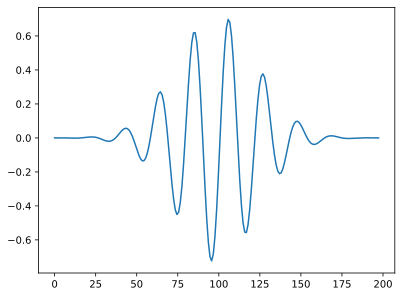

In [14]:
pulse = gaussian_pulse(tlist, {'w_d': 7, 'amp':amp_with_2pi/2*np.pi, 't_duration': t_tot, 'sigma':sigma})
plt.plot(tlist,pulse)

In [15]:
fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
tune_tmon = scqubits.TunableTransmon(
    EJmax=50,
    EC=0.5,
    d=0.01,
    flux=flux,
    ng=0.0,
    ncut=30,
    truncated_dim = 4
    )
system = FluxoniumTunableTransmonSystem(
    fluxonium  = fluxonium,
    tune_tmon = tune_tmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    )


In [16]:

w_d = system.evals[system.product_to_dressed[(0,1)]] - system.evals[system.product_to_dressed[(0,0)]]
w_d

7.223640752620059

In [17]:
e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))
e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(7,0)]))))
results = system.run_qutip_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.tune_tmon.n_operator)),
                # pulse_shape_func=square_pulse_with_rise_fall,
                # pulse_shape_args={
                #     'w_d': w_d,
                #     'amp': amp_with_2pi/(2*np.pi),
                #     't_rise': t_rise,
                #     't_square': pulse_length - t_rise
                #   },
                pulse_shape_func=gaussian_pulse,
                pulse_shape_args={
                    'w_d': w_d,
                    'amp': amp_with_2pi/(2*np.pi),
                    't_duration': t_tot, 
                    'sigma':sigma
                    },
                )],
        c_ops = None,
        e_ops = e_ops
    )


 Total run time:   5.99s*] Elapsed 5.99s / Remaining 00:00:00:00 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00
 Total run time:   6.01s*] Elapsed 6.01s / Remaining 00:00:00:00
 [*********82%*******    ] Elapsed 6.17s / Remaining 00:00:00:01

Processing states with pad_back_custom: 100%|██████████| 197/197 [00:00<00:00, 6317.98it/s]


 Total run time:   7.36s*] Elapsed 7.36s / Remaining 00:00:00:00


Processing states with pad_back_custom: 100%|██████████| 197/197 [00:00<00:00, 6260.30it/s]


In [18]:
len(results[0].expect)

33

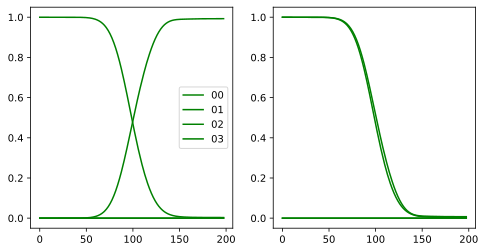

In [19]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(1,2,figsize = (8,4))
for ql in range(1):
    for tl in range(4):
        i = ql*4+tl

        axes[0].plot(tlist,results[ql].expect[i],label = f"{ql}{tl}",color = colors[ql])
        
        axes[1].plot(tlist,results[ql].expect[i] if not (ql == 0 and tl ==1)  else 1- results[ql].expect[i],label = f"{ql}{tl}",color = colors[ql])

axes[0].legend()
# axes[1].set_ylim(0,0.02)

(-0.001, 0.02)

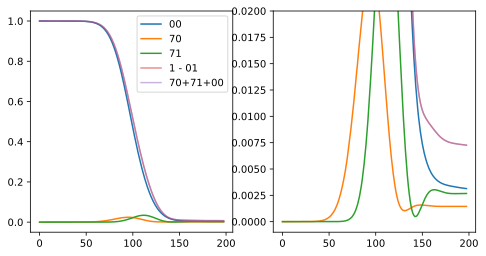

In [20]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(1,2,figsize = (8,4))
for ql,tl in [(0,0),(7,0),(7,1)]:
    i = ql*4+tl
    axes[0].plot(tlist,results[0].expect[i],label = f"{ql}{tl}")
axes[0].plot(tlist,1 - results[0].expect[1],label = f"1 - 01",alpha = 0.5)
axes[0].plot(tlist,results[0].expect[4*7+0] + results[0].expect[4*7+1] + results[0].expect[0] ,label = f"70+71+00",alpha = 0.5)


for ql,tl in [(0,0),(7,0),(7,1)]:
    i = ql*4+tl
    axes[1].plot(tlist,results[0].expect[i],label = f"{ql}{tl}")
axes[1].plot(tlist,1 - results[0].expect[1],label = f"1 - 01",alpha = 0.5)
axes[1].plot(tlist,results[0].expect[4*7+0] + results[0].expect[4*7+1] + results[0].expect[0] ,label = f"70+71+00",alpha = 0.5)



axes[0].legend()
axes[1].set_ylim(-0.001,0.02)

In [55]:
system.evals[system.product_to_dressed[(7,0)]] - system.evals[system.product_to_dressed[(0,0)]]

7.2482838496893915

In [56]:
system.evals[system.product_to_dressed[(0,1)]] - system.evals[system.product_to_dressed[(0,0)]]

7.223640752620059

In [31]:
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)


print(f"\t\tqubit 0\t\t\tqubit 1 \t\t qubit 2")

print(f"osc lvl\t\tdressed-overlap^2\tdressed-overlap^2\tdressed-overlap^2")
for i in range(10):
    product_index_q0 = 0 * system.tune_tmon.truncated_dim + i
    product_index_q1 = 1 * system.tune_tmon.truncated_dim + i
    product_index_q2 = 2 * system.tune_tmon.truncated_dim + i

    overlaps_with_product_state_q0 = np.abs(overlap_matrix[:, product_index_q0])
    sorted_indices_q0 = np.argsort(overlaps_with_product_state_q0)[::-1]
    sorted_overlaps_q0 = overlaps_with_product_state_q0[sorted_indices_q0]

    overlaps_with_product_state_q1 = np.abs(overlap_matrix[:, product_index_q1])
    sorted_indices_q1 = np.argsort(overlaps_with_product_state_q1)[::-1]
    sorted_overlaps_q1 = overlaps_with_product_state_q1[sorted_indices_q1]
    
    overlaps_with_product_state_q2 = np.abs(overlap_matrix[:, product_index_q2])
    sorted_indices_q2 = np.argsort(overlaps_with_product_state_q2)[::-1]
    sorted_overlaps_q2 = overlaps_with_product_state_q2[sorted_indices_q2]

    print(f"tl-{i}:\t\t{list(sorted_indices_q0)[0]}-{list(sorted_overlaps_q0)[0]**2:.3f} \t\t{list(sorted_indices_q1)[0]}-{list(sorted_overlaps_q1)[0]**2:.3f} \t\t{list(sorted_indices_q2)[0]}-{list(sorted_overlaps_q2)[0]**2:.3f}")

		qubit 0			qubit 1 		 qubit 2
osc lvl		dressed-overlap^2	dressed-overlap^2	dressed-overlap^2
tl-0:		0-1.000 		1-1.000 		2-1.000
tl-1:		7-0.521 		12-0.998 		13-0.998
tl-2:		24-0.997 		29-0.998 		30-0.994
tl-3:		42-0.996 		48-0.993 		49-0.995
tl-4:		1-1.000 		2-1.000 		3-0.999
tl-5:		12-0.998 		13-0.998 		15-0.995
tl-6:		29-0.998 		30-0.994 		34-0.983
tl-7:		48-0.993 		49-0.995 		51-0.991
tl-8:		2-1.000 		3-0.999 		4-0.999
tl-9:		13-0.998 		15-0.995 		18-0.995
